In [2]:
"""
Arabic End-of-Utterance (EOU) Detection - Complete Training Pipeline
Optimized for Google Colab with A100 GPU

Run this in Google Colab with A100 GPU for best performance
Runtime -> Change runtime type -> A100 GPU
"""

'\nArabic End-of-Utterance (EOU) Detection - Complete Training Pipeline\nOptimized for Google Colab with A100 GPU\n\nRun this in Google Colab with A100 GPU for best performance\nRuntime -> Change runtime type -> A100 GPU\n'

In [3]:
# ============================================================================
# Setup and Installation
# ============================================================================

print("Installing required packages...")
!pip install -q transformers datasets torch scikit-learn pandas numpy accelerate
!pip install -q evaluate sentencepiece huggingface_hub

print("✓ Packages installed successfully!")

Installing required packages...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 6.9 MB/s eta 0:00:00
✓ Packages installed successfully!


In [4]:
import os
dataset_path = '/content/eou_dataset_clean.jsonl'

In [5]:
# ============================================================================
# Check GPU and Setup
# ============================================================================

import torch
import json
import pandas as pd
import numpy as np
from collections import Counter
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, classification_report
import seaborn as sns

print("=" * 80)
print("GPU CHECK")
print("=" * 80)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\nDevice: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
    print(f"CUDA Version: {torch.version.cuda}")
else:
    print(" WARNING: No GPU detected! Training will be very slow.")
    print("Please change runtime: Runtime -> Change runtime type -> A100 GPU")


GPU CHECK

Device: cuda
GPU: NVIDIA A100-SXM4-40GB
GPU Memory: 42.47 GB
CUDA Version: 12.6


In [6]:
# ============================================================================
# Load and Explore Dataset
# ============================================================================

print("\n" + "=" * 80)
print("LOADING DATASET")
print("=" * 80)

# Load the dataset
data = []
with open(dataset_path, 'r', encoding='utf-8') as f:
    for line in f:
        data.append(json.loads(line))

df = pd.DataFrame(data)
print(f"\nOriginal dataset size: {len(df):,}")
print(f"\nLabel distribution:")
print(df['label'].value_counts())
print(f"\nPercentage:")
print(df['label'].value_counts(normalize=True) * 100)

# Display sample
print(f"\nSample data:")
print(df[['text', 'label', 'silence_after_seconds']].head(3))


LOADING DATASET

Original dataset size: 414,053

Label distribution:
label
1    311206
0    102847
Name: count, dtype: int64

Percentage:
label
1    75.160909
0    24.839091
Name: proportion, dtype: float64

Sample data:
                           text  label  silence_after_seconds
0            ووضح كلامك يا مغيث      1                   0.86
1  ترى راسي ما عاد يتحمل الغازك      1                   0.71
2       سلامة راسك يا ابو مسامح      1                   1.38



DATA SAMPLING STRATEGY (A100 Optimized)

Using 15.0% of data for training
This is optimized for A100 GPU - training should take 20-30 minutes

Sampled dataset size: 62,107
Sampled label distribution:
label
1    46680
0    15427
Name: count, dtype: int64

Final splits:
  Train: 49,685 samples
  Validation: 6,211 samples
  Test: 6,211 samples


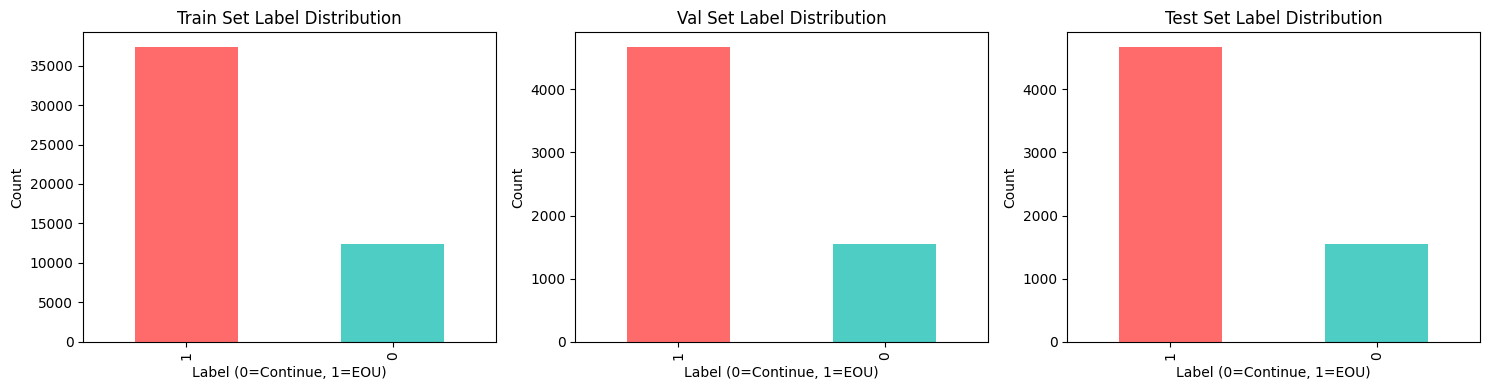


Class weights for handling imbalance:
  Class 0 (No EOU): 2.0130
  Class 1 (EOU): 0.6652


In [7]:
# ============================================================================
# Data Sampling and Splitting (Optimized for A100)
# ============================================================================

print("\n" + "=" * 80)
print("DATA SAMPLING STRATEGY (A100 Optimized)")
print("=" * 80)

# For A100, we can use more data for better results
SAMPLE_FRACTION = 0.15  # 15% of data (~62K samples) - good balance for A100
RANDOM_SEED = 42

print(f"\nUsing {SAMPLE_FRACTION*100}% of data for training")
print("This is optimized for A100 GPU - training should take 20-30 minutes")

# Stratified sampling
df_sampled, _ = train_test_split(
    df,
    train_size=SAMPLE_FRACTION,
    stratify=df['label'],
    random_state=RANDOM_SEED
)

print(f"\nSampled dataset size: {len(df_sampled):,}")
print(f"Sampled label distribution:")
print(df_sampled['label'].value_counts())

# Split into train/val/test (80/10/10)
train_df, temp_df = train_test_split(
    df_sampled,
    test_size=0.2,
    stratify=df_sampled['label'],
    random_state=RANDOM_SEED
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    stratify=temp_df['label'],
    random_state=RANDOM_SEED
)

print(f"\nFinal splits:")
print(f"  Train: {len(train_df):,} samples")
print(f"  Validation: {len(val_df):,} samples")
print(f"  Test: {len(test_df):,} samples")

# Visualize
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for idx, (name, data) in enumerate([('Train', train_df), ('Val', val_df), ('Test', test_df)]):
    data['label'].value_counts().plot(kind='bar', ax=axes[idx], color=['#ff6b6b', '#4ecdc4'])
    axes[idx].set_title(f'{name} Set Label Distribution')
    axes[idx].set_xlabel('Label (0=Continue, 1=EOU)')
    axes[idx].set_ylabel('Count')
plt.tight_layout()
plt.show()

# Calculate class weights
class_counts = train_df['label'].value_counts()
total = len(train_df)
class_weights = {
    0: total / (2 * class_counts[0]),
    1: total / (2 * class_counts[1])
}

print(f"\nClass weights for handling imbalance:")
print(f"  Class 0 (No EOU): {class_weights[0]:.4f}")
print(f"  Class 1 (EOU): {class_weights[1]:.4f}")


In [8]:
# ============================================================================
# Prepare Text Data
# ============================================================================

print("\n" + "=" * 80)
print("TEXT PREPARATION")
print("=" * 80)

# Use text with pause markers
train_df['model_input'] = train_df['text_with_pause']
val_df['model_input'] = val_df['text_with_pause']
test_df['model_input'] = test_df['text_with_pause']

print("Sample inputs:")
for i in range(3):
    print(f"\n{i+1}. Text: {train_df.iloc[i]['model_input']}")
    print(f"   Label: {train_df.iloc[i]['label']} ({'EOU' if train_df.iloc[i]['label']==1 else 'Continue'})")



TEXT PREPARATION
Sample inputs:

1. Text: سبانخ استخدم السبانخ الصغير لا تستخدم ورق السبانخ الكبير يعطي مروره اذا انت من الناس تروح النادي تمرين ممكن تستخدم هذا العصير بعد النادي طبعا الكمية هذه كبيرة مش حق شخص واحد وتحط عليها الكمية الكوب مع ون كوب بروتين فانيلا وايضا رح نزيد عليها شوية ماي عشان بس نساعد عملية الضرب [PAUSE_7.16]
   Label: 1 (EOU)

2. Text: الله يحييك ويسماك اممم
   Label: 0 (Continue)

3. Text: الكلام هذا ما يمشي عندي [PAUSE_0.72]
   Label: 0 (Continue)


In [9]:
# ============================================================================
# Load Model and Tokenizer
# ============================================================================

from transformers import AutoTokenizer, AutoModelForSequenceClassification

print("\n" + "=" * 80)
print("LOADING MODEL")
print("=" * 80)

MODEL_NAME = "aubmindlab/bert-base-arabertv2"
print(f"\nModel: {MODEL_NAME}")
print("This model is specifically trained on Arabic dialects including Saudi")

# Load tokenizer
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
print(f"✓ Tokenizer loaded")

# Load model
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2,
    problem_type="single_label_classification"
)

print(f"✓ Model loaded")
print(f"  Parameters: {sum(p.numel() for p in model.parameters()) / 1e6:.1f}M")


LOADING MODEL

Model: aubmindlab/bert-base-arabertv2
This model is specifically trained on Arabic dialects including Saudi


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/611 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/384 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

✓ Tokenizer loaded


model.safetensors:   0%|          | 0.00/543M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at aubmindlab/bert-base-arabertv2 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


✓ Model loaded
  Parameters: 135.2M


In [10]:
# ============================================================================
# Tokenize Datasets
# ============================================================================

from datasets import Dataset as HFDataset

print("\n" + "=" * 80)
print("TOKENIZING DATASETS")
print("=" * 80)

def tokenize_function(examples):
    return tokenizer(
        examples['model_input'],
        padding='max_length',
        truncation=True,
        max_length=128,
        return_tensors='pt'
    )

# Convert to HuggingFace datasets
train_dataset = HFDataset.from_pandas(train_df[['model_input', 'label']])
val_dataset = HFDataset.from_pandas(val_df[['model_input', 'label']])
test_dataset = HFDataset.from_pandas(test_df[['model_input', 'label']])

# Tokenize
print("Tokenizing...")
train_dataset = train_dataset.map(tokenize_function, batched=True, remove_columns=['model_input'])
val_dataset = val_dataset.map(tokenize_function, batched=True, remove_columns=['model_input'])
test_dataset = test_dataset.map(tokenize_function, batched=True, remove_columns=['model_input'])

# Set format
train_dataset.set_format(type='torch', columns=['input_ids', 'attention_mask', 'label'])
val_dataset.set_format(type='torch', columns=['input_ids', 'attention_mask', 'label'])
test_dataset.set_format(type='torch', columns=['input_ids', 'attention_mask', 'label'])

print("✓ Tokenization complete")


TOKENIZING DATASETS
Tokenizing...


Map:   0%|          | 0/49685 [00:00<?, ? examples/s]

Map:   0%|          | 0/6211 [00:00<?, ? examples/s]

Map:   0%|          | 0/6211 [00:00<?, ? examples/s]

✓ Tokenization complete


In [11]:
# ============================================================================
# Setup Custom Trainer with Class Weights
# ============================================================================

from transformers import Trainer, TrainingArguments, EarlyStoppingCallback

class WeightedTrainer(Trainer):
    def __init__(self, *args, class_weights=None, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights

    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits

        # Apply class weights
        if self.class_weights is not None:
            weight = torch.tensor([
                float(self.class_weights[0]),
                float(self.class_weights[1])
            ]).to(logits.device)
            loss_fct = torch.nn.CrossEntropyLoss(weight=weight)
        else:
            loss_fct = torch.nn.CrossEntropyLoss()

        loss = loss_fct(logits, labels)
        return (loss, outputs) if return_outputs else loss

def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, predictions, average='binary', pos_label=1
    )
    acc = accuracy_score(labels, predictions)

    return {
        'accuracy': acc,
        'f1': f1,
        'precision': precision,
        'recall': recall
    }

print("\n✓ Custom trainer and metrics defined")


✓ Custom trainer and metrics defined


In [12]:
# ============================================================================
# Training Configuration (A100 Optimized)
# ============================================================================

print("\n" + "=" * 80)
print("TRAINING CONFIGURATION (A100 Optimized)")
print("=" * 80)

training_args = TrainingArguments(
    output_dir='./eou_model_checkpoints',
    eval_strategy='steps',
    eval_steps=150,
    save_strategy='steps',
    save_steps=150,
    learning_rate=3e-5,
    per_device_train_batch_size=64,  # A100 can handle large batches
    per_device_eval_batch_size=128,
    num_train_epochs=4,  # More epochs for better results
    weight_decay=0.01,
    warmup_steps=200,
    logging_steps=50,
    load_best_model_at_end=True,
    metric_for_best_model='f1',
    greater_is_better=True,
    save_total_limit=2,
    fp16=True,  # Mixed precision for A100
    dataloader_num_workers=2,  # Parallel data loading
    gradient_accumulation_steps=1,
    max_grad_norm=1.0,
    report_to='none',
    seed=42
)

print("\nTraining configuration:")
print(f"  Epochs: {training_args.num_train_epochs}")
print(f"  Batch size: {training_args.per_device_train_batch_size}")
print(f"  Effective batch size: {training_args.per_device_train_batch_size * training_args.gradient_accumulation_steps}")
print(f"  Learning rate: {training_args.learning_rate}")
print(f"  FP16: {training_args.fp16}")
print(f"  Estimated training time: 20-30 minutes on A100")


TRAINING CONFIGURATION (A100 Optimized)

Training configuration:
  Epochs: 4
  Batch size: 64
  Effective batch size: 64
  Learning rate: 3e-05
  FP16: True
  Estimated training time: 20-30 minutes on A100


In [13]:
# ============================================================================
# CELL 11: Train the Model
# ============================================================================

print("\n" + "=" * 80)
print("STARTING TRAINING")
print("=" * 80)

trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
    class_weights=class_weights,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)]
)



# Train
train_result = trainer.train()

print("\n" + "=" * 80)
print("✓ TRAINING COMPLETED!")
print("=" * 80)
print(f"\nFinal training loss: {train_result.training_loss:.4f}")



STARTING TRAINING


Step,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
150,0.263100,0.211429,0.905490,0.933242,0.994667,0.878963
300,0.205000,0.195833,0.905490,0.932907,1.000000,0.874250
450,0.198300,0.193072,0.905490,0.932937,0.999510,0.874679
600,0.205900,0.200574,0.906456,0.933789,0.997565,0.877678
750,0.198600,0.194181,0.905651,0.933029,1.000000,0.874464
900,0.200600,0.194756,0.905490,0.932907,1.000000,0.874250
1050,0.193400,0.191421,0.905490,0.932907,1.000000,0.874250



✓ TRAINING COMPLETED!

Final training loss: 0.2347



MODEL EVALUATION

 Validation Set Metrics:


  eval_loss: 0.2006
  eval_accuracy: 0.9065
  eval_f1: 0.9338
  eval_precision: 0.9976
  eval_recall: 0.8777
  eval_samples_per_second: 4148.6950
  eval_steps_per_second: 32.7300
  epoch: 1.3514

 Test Set Metrics:
  eval_loss: 0.1964
  eval_accuracy: 0.9068
  eval_f1: 0.9340
  eval_precision: 0.9983
  eval_recall: 0.8775
  eval_samples_per_second: 4156.3380
  eval_steps_per_second: 32.7900
  epoch: 1.3514


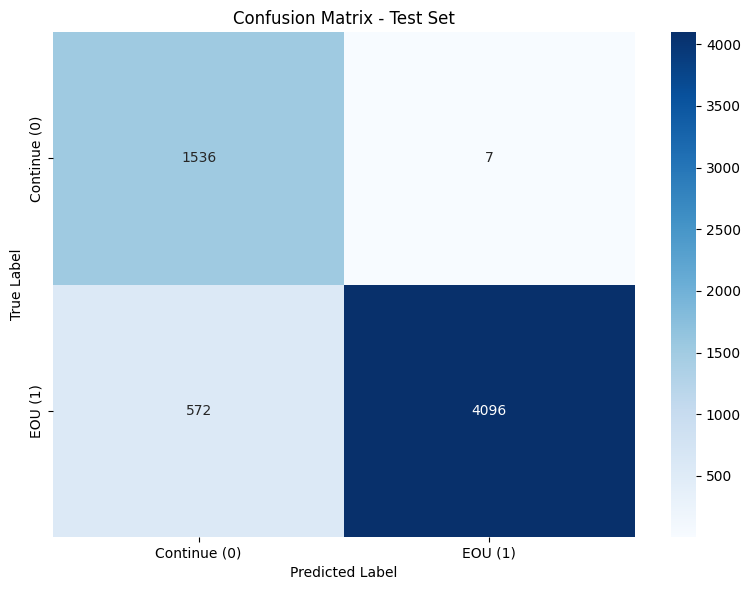


 Detailed Classification Report:
              precision    recall  f1-score   support

  No EOU (0)       0.73      1.00      0.84      1543
     EOU (1)       1.00      0.88      0.93      4668

    accuracy                           0.91      6211
   macro avg       0.86      0.94      0.89      6211
weighted avg       0.93      0.91      0.91      6211



In [14]:
# ============================================================================
# Evaluate Model
# ============================================================================

print("\n" + "=" * 80)
print("MODEL EVALUATION")
print("=" * 80)

# Validation metrics
print("\n Validation Set Metrics:")
val_metrics = trainer.evaluate(eval_dataset=val_dataset)
for key, value in val_metrics.items():
    if not key.startswith('eval_runtime'):
        print(f"  {key}: {value:.4f}")

# Test metrics
print("\n Test Set Metrics:")
test_metrics = trainer.evaluate(eval_dataset=test_dataset)
for key, value in test_metrics.items():
    if not key.startswith('eval_runtime'):
        print(f"  {key}: {value:.4f}")

# Get predictions
predictions = trainer.predict(test_dataset)
pred_labels = np.argmax(predictions.predictions, axis=1)
true_labels = predictions.label_ids

# Confusion matrix
cm = confusion_matrix(true_labels, pred_labels)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Continue (0)', 'EOU (1)'],
            yticklabels=['Continue (0)', 'EOU (1)'])
plt.title('Confusion Matrix - Test Set')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

# Classification report
print("\n Detailed Classification Report:")
print(classification_report(true_labels, pred_labels,
                          target_names=['No EOU (0)', 'EOU (1)']))

In [15]:
# ============================================================================
# Save Model
# ============================================================================

print("\n" + "=" * 80)
print("SAVING MODEL")
print("=" * 80)

# Save locally
model.save_pretrained('./arabic_eou_model')
tokenizer.save_pretrained('./arabic_eou_model')
print("✓ Model saved to './arabic_eou_model'")

# Save metrics
results = {
    'model_name': MODEL_NAME,
    'training_samples': len(train_df),
    'val_samples': len(val_df),
    'test_samples': len(test_df),
    'validation_metrics': {k: float(v) for k, v in val_metrics.items() if isinstance(v, (int, float))},
    'test_metrics': {k: float(v) for k, v in test_metrics.items() if isinstance(v, (int, float))},
    'training_loss': float(train_result.training_loss),
    'class_weights': class_weights
}

with open('./arabic_eou_model/training_results.json', 'w') as f:
    json.dump(results, f, indent=2)

print("✓ Training results saved")


SAVING MODEL
✓ Model saved to './arabic_eou_model'
✓ Training results saved


In [16]:
# ============================================================================
# Test Inference
# ============================================================================

print("\n" + "=" * 80)
print("TESTING INFERENCE")
print("=" * 80)

model.eval()
model.to(device)

def predict_eou(text, show_details=True):
    """Predict end-of-utterance probability"""
    inputs = tokenizer(text, return_tensors='pt', truncation=True, max_length=128)
    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs)
        probs = torch.nn.functional.softmax(outputs.logits, dim=-1)
        eou_prob = probs[0][1].item()
        continue_prob = probs[0][0].item()

    if show_details:
        print(f"\nText: {text}")
        print(f"  Continue probability: {continue_prob:.4f}")
        print(f"  EOU probability: {eou_prob:.4f}")
        print(f"  → Prediction: {'✓ EOU (End of Turn)' if eou_prob > 0.5 else '→ Continue Speaking'}")

    return eou_prob

# Test samples
test_samples = [
    "ووضح كلامك يا مغيث [PAUSE_0.86]",
    "أنا ذاهب إلى",
    "شكرا لك على المساعدة [PAUSE_1.2]",
    "وبعدين",
    "تمام كذا [PAUSE_0.95]",
    "بس أنا أقول",
]

print("\n Testing model predictions:\n")
for text in test_samples:
    predict_eou(text)


TESTING INFERENCE

 Testing model predictions:


Text: ووضح كلامك يا مغيث [PAUSE_0.86]
  Continue probability: 0.0003
  EOU probability: 0.9997
  → Prediction: ✓ EOU (End of Turn)

Text: أنا ذاهب إلى
  Continue probability: 0.8344
  EOU probability: 0.1656
  → Prediction: → Continue Speaking

Text: شكرا لك على المساعدة [PAUSE_1.2]
  Continue probability: 0.0003
  EOU probability: 0.9997
  → Prediction: ✓ EOU (End of Turn)

Text: وبعدين
  Continue probability: 0.8632
  EOU probability: 0.1368
  → Prediction: → Continue Speaking

Text: تمام كذا [PAUSE_0.95]
  Continue probability: 0.0003
  EOU probability: 0.9997
  → Prediction: ✓ EOU (End of Turn)

Text: بس أنا أقول
  Continue probability: 0.8207
  EOU probability: 0.1793
  → Prediction: → Continue Speaking


In [ ]:
# ============================================================================
# Upload to Hugging Face Hub
# ============================================================================

print("\n" + "=" * 80)
print("UPLOAD TO HUGGING FACE HUB")
print("=" * 80)

print("\nTo upload your model to Hugging Face:")
print("\n1. Login to Hugging Face:")
print("   !huggingface-cli login")
print("\n2. Push the model:")
print("   from huggingface_hub import HfApi")
print("   api = HfApi()")
print("   api.upload_folder(")
print("       folder_path='./arabic_eou_model',")
print("       repo_id='your-username/arabic-eou-model',")
print("       repo_type='model'")
print("   )")

# Uncomment to upload
# from huggingface_hub import notebook_login
# notebook_login()

In [17]:
# ============================================================================
# Download Model for Local Use
# ============================================================================

print("\n" + "=" * 80)
print("DOWNLOAD MODEL")
print("=" * 80)

# Zip the model
!zip -r arabic_eou_model.zip ./arabic_eou_model/

print("\n✓ Model zipped as 'arabic_eou_model.zip'")
print("\nDownload the model:")

from google.colab import files
files.download('arabic_eou_model.zip')


DOWNLOAD MODEL
  adding: arabic_eou_model/ (stored 0%)
  adding: arabic_eou_model/model.safetensors (deflated 7%)
  adding: arabic_eou_model/special_tokens_map.json (deflated 80%)
  adding: arabic_eou_model/tokenizer.json (deflated 73%)
  adding: arabic_eou_model/tokenizer_config.json (deflated 90%)
  adding: arabic_eou_model/config.json (deflated 50%)
  adding: arabic_eou_model/training_results.json (deflated 60%)
  adding: arabic_eou_model/vocab.txt (deflated 62%)

✓ Model zipped as 'arabic_eou_model.zip'

Download the model:


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>